В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

Area under ROC score on Training dataset: 88.25%


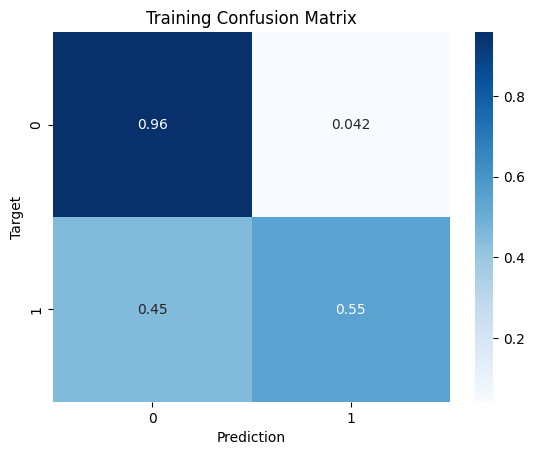

Area under ROC score on Validation dataset: 87.97%


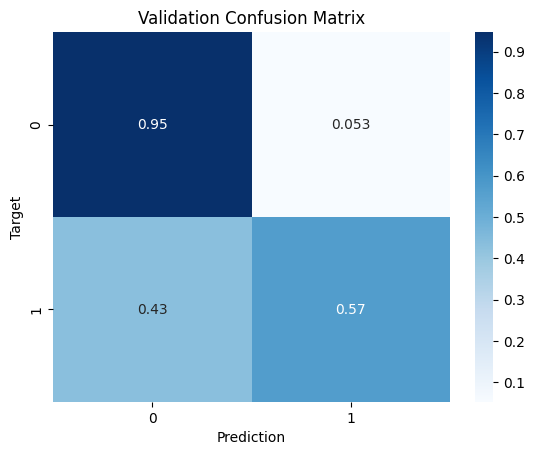

['log_reg_pipeline.joblib']

In [1]:
# Попередня обробка даних
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

train_df = pd.read_csv("/content/train.csv")

train_tr_df, train_val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['Exited'])

# назви колонок, які сформують вхідні незалежні дані
# підготовка даних для входу в модель
target_col = 'Exited'
cols_to_drop = ['id', 'CustomerId', 'Surname']
input_cols = [col for col in train_df.columns if col != target_col and col not in cols_to_drop]

train_inputs, train_targets = train_tr_df[input_cols], train_tr_df[target_col]
val_inputs, val_targets = train_val_df[input_cols], train_val_df[target_col]

# назви колонок, які є числовими і категоріальними
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(transformers=[
    # ('назва', який_трансформер, для_яких_колонок)
      ('num', numeric_transformer, numeric_cols),
      ('cat', categorical_transformer, categorical_cols)
])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),          # готуємо дані
    ('classifier', LogisticRegression())     # передаємо готові дані в модель
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, y_probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc*100:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# викликаємо функцію для тренувальних та валідаційних даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [3]:
from sklearn.preprocessing import PolynomialFeatures
numeric_transformer_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # поліноми 2-го степеня
    ('scaler', StandardScaler())
])

In [4]:
numeric_transformer_poly

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler())])

Area under ROC score on Training dataset: 93.03%


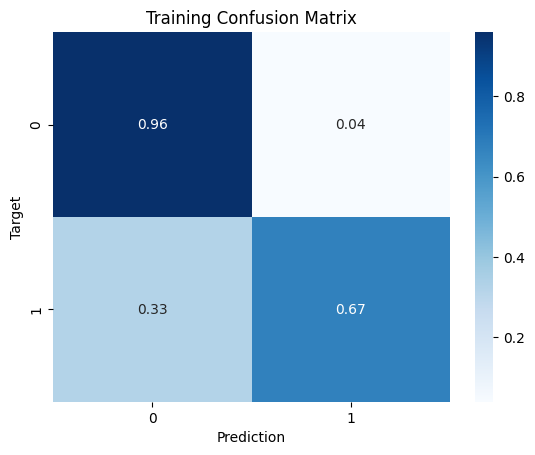

Area under ROC score on Validation dataset: 92.75%


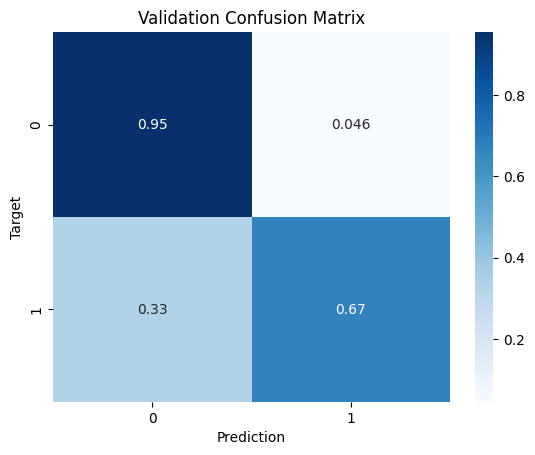

In [6]:
preprocessor_poly = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer_poly, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

In [9]:
trained_preprocessor = model_pipeline_poly.named_steps['preprocessor']
feature_names = trained_preprocessor.get_feature_names_out()
print(f"Загальна кількість колонок, яку отримала модель: {len(feature_names)}")

Загальна кількість колонок, яку отримала модель: 49


Якість передбачення покращилася (ROC-AUC зріс приблизно на 5%). Модель добре генералізує.  
Різниця між Training та Validation незначна, тож Overfitting немає.
Underfit теж не має, тому що попри додавання нових ознак модель покращила свої метрикі.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Training dataset: 93.94%


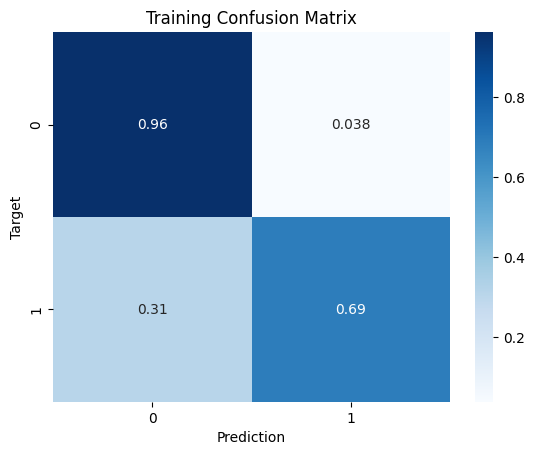

Area under ROC score on Validation dataset: 93.23%


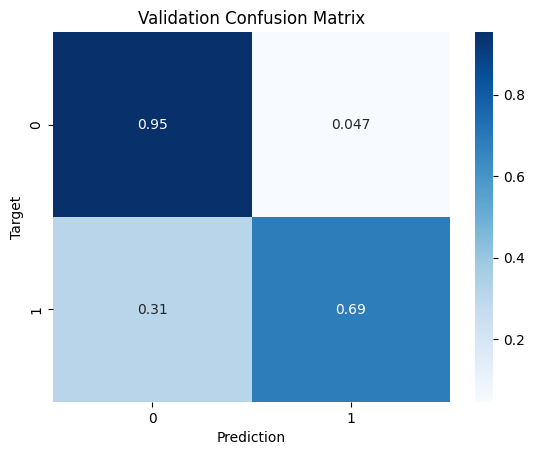

In [7]:
numeric_transformer_poly_new = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly_new = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer_poly_new, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

model_pipeline_poly_new = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_new),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly_new.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_poly_new, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_poly_new, val_inputs, val_targets, 'Validation')

In [8]:
trained_preprocessor = model_pipeline_poly_new.named_steps['preprocessor']
feature_names = trained_preprocessor.get_feature_names_out()
print(f"Загальна кількість колонок, яку отримала модель: {len(feature_names)}")

Загальна кількість колонок, яку отримала модель: 499


Метрики змінилися незначно (приріст менше ніж 1%). Це означає, що додавання поліномів 4-го степенів не принесло моделі нової корисної інформації.  
Модель добре генералізує але приріст якості (499 додаткових колонок) не вартий такої важкості та ускладнення моделі.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [10]:
df = pd.read_csv("/content/regression_data.csv")
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42)

target_col = 'target'
input_cols = [col for col in df.columns if col != target_col]

train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

name_cols = train_inputs.columns.tolist()

In [12]:
model_pipeline_regression = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])

model_pipeline_regression.fit(train_inputs, train_targets)

train_preds = model_pipeline_regression.predict(train_inputs)
test_preds = model_pipeline_regression.predict(test_inputs)

print("--- Метрики для Тренувального набору ---")
print(f"R² Score: {r2_score(train_targets, train_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(train_targets, train_preds)):.4f}")

print("\n--- Метрики для Тестового набору ---")
print(f"R² Score: {r2_score(test_targets, test_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_targets, test_preds)):.4f}")

--- Метрики для Тренувального набору ---
R² Score: 1.0000
RMSE: 0.0000

--- Метрики для Тестового набору ---
R² Score: 0.9311
RMSE: 12.6767


На тренувальних даних модель помиляється рівно на 0%. Вона побудувала складну криву (через 5-й степінь поліномів) і ця крива пройшла ідеально через кожну крапку тренувальних даних.  
Але на тестових даних модель вже має помилку RMSE 12.67% і це означає що модель погано генералізує.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [14]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
model_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0))
])

model_lasso = Pipeline([
     ('poly', PolynomialFeatures(degree=20, include_bias=False)),
     ('scaler', StandardScaler()),
     ('regressor', Lasso(alpha=0.1, max_iter=10000))
])

model_elastic = Pipeline([
     ('poly', PolynomialFeatures(degree=20, include_bias=False)),
     ('scaler', StandardScaler()),
     ('regressor', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])

model_ridge.fit(train_inputs, train_targets)
model_lasso.fit(train_inputs, train_targets)
model_elastic.fit(train_inputs, train_targets)

train_preds_ridge = model_ridge.predict(train_inputs)
test_preds_ridge = model_ridge.predict(test_inputs)

train_preds_lasso = model_lasso.predict(train_inputs)
test_preds_lasso = model_lasso.predict(test_inputs)

train_preds_elastic = model_elastic.predict(train_inputs)
test_preds_elastic = model_elastic.predict(test_inputs)

r2_ridge_train = r2_score(train_targets, train_preds_ridge)
r2_ridge_test = r2_score(test_targets, test_preds_ridge)
rmse_ridge_train = np.sqrt(mean_squared_error(train_targets, train_preds_ridge))
rmse_ridge_test = np.sqrt(mean_squared_error(test_targets, test_preds_ridge))

r2_lasso_train = r2_score(train_targets, train_preds_lasso)
r2_lasso_test = r2_score(test_targets, test_preds_lasso)
rmse_lasso_train = np.sqrt(mean_squared_error(train_targets, train_preds_lasso))
rmse_lasso_test = np.sqrt(mean_squared_error(test_targets, test_preds_lasso))

r2_elastic_train = r2_score(train_targets, train_preds_elastic)
r2_elastic_test = r2_score(test_targets, test_preds_elastic)
rmse_elastic_train = np.sqrt(mean_squared_error(train_targets, train_preds_elastic))
rmse_elastic_test = np.sqrt(mean_squared_error(test_targets, test_preds_elastic))

print("--- Метрики для Тренувального / Тестового набору ---")
print("Ridge:")
print(f"R² Score: {r2_ridge_train:.4f} / {r2_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge_train:.4f} / {rmse_ridge_test:.4f}")

print("\nLasso")
print(f"R² Score: {r2_lasso_train:.4f} / {r2_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso_train:.4f} / {rmse_lasso_test:.4f}")

print("\nElasticNet")
print(f"R² Score: {r2_elastic_train:.4f} / {r2_elastic_test:.4f}")
print(f"RMSE: {rmse_elastic_train:.4f} / {rmse_elastic_test:.4f}")

--- Метрики для Тренувального / Тестового набору ---
Ridge:
R² Score: 0.9994 / 0.6688
RMSE: 1.0537 / 27.7976

Lasso
R² Score: 0.9995 / 0.9993
RMSE: 0.9645 / 1.2771

ElasticNet
R² Score: 0.9946 / 0.9761
RMSE: 3.2571 / 7.4709


Найкраще генералізує модель Lasso, т.я. у неї високий R^2 = 0.99 на тестових даних та найменша помилку RMSE = 1.27  
Кожна модель згенерувала однакову кількість ознак (через 5-й степінь поліномів) але могла використати різну кількість активних ознак та проігнорувати на її погляд "не еффективні". Тому потрібен додатковий аналіз ознак.